# Ejercicio Práctico 1: Análisis de estrategias de opciones con datos reales
Jesus Alejandro Garcia Garcia

Usando yfinance, descarga la cadena de opciones vigente de un activo de tu elección con opciones líquidas.
Selecciona los contratos necesarios para construir dos de las siguientes estrategias (cada estudiante elige cuáles):
- Long straddle
- Bull call spread
- Bear put spread
- Iron condor
- Protective put

Para cada estrategia: grafica el diagrama de payoff al vencimiento, e indica claramente el breakeven, la ganancia máxima y la pérdida máxima.
Reporta las Griegas individuales de cada contrato usado (Delta, Gamma, Theta, Vega) tomándolas de la cadena de opciones o calculándolas con Black-Scholes. Calcula las Griegas netas del portafolio resultante de cada estrategia.

En markdown: explica en qué condición de mercado (dirección esperada y nivel de volatilidad) tiene sentido cada estrategia construida. Vincula explícitamente tu respuesta con el signo e interpretación de al menos dos Griegas netas calculadas.

Entregable: link a notebook en Colab o GitHub (.py con PDF/markdown adjunto). Código limpio, comentado y con gráficas claras.

Rúbrica (30 pts):

- Descarga de cadena de opciones y selección de contratos (3 pts): uso correcto de yfinance, contratos reales identificados claramente.
- Construcción de las dos estrategias (4 pts): lógica correcta de cada estrategia, posiciones largas/cortas bien definidas.
- Diagramas de payoff (10 pts, 5 por estrategia): gráfica clara, breakeven correcto, ganancia y pérdida máxima identificadas.
- Griegas individuales y netas (9 pts, 4.5 por estrategia): Griegas reportadas por contrato, suma neta correcta del portafolio.
- Análisis en markdown (4 pts): condición de mercado correctamente identificada para cada estrategia, vínculo explícito con al menos dos Griegas netas.

Activo: MSFT | Spot Actual: $405.21
Expiración seleccionada: 2026-05-22


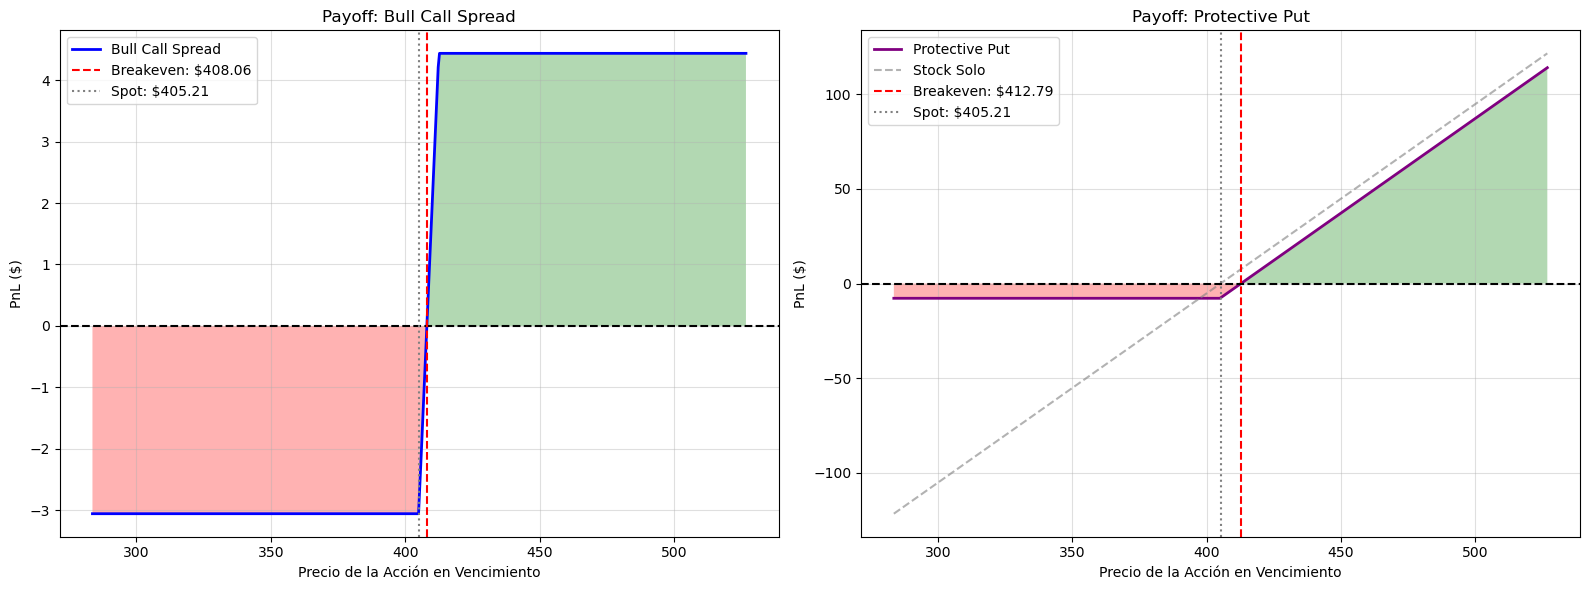


ESTRATEGIA 1: BULL CALL SPREAD
Long Call (K=$405.00) | Costo: $7.50 | D: 0.522, G: 0.0218, T: -0.481, V: 0.239
Short Call (K=$412.50) | Prima: $4.44 | D: 0.361, G: 0.0208, T: -0.440, V: 0.225
--------------------------------------------------
Max Ganancia: $4.44
Max Pérdida: -$-3.06
Breakeven: $408.06
GRIEGAS NETAS -> Delta: 0.161 | Gamma: 0.0010 | Theta: -0.041 | Vega: 0.014

ESTRATEGIA 2: PROTECTIVE PUT
Long Stock (S0=$405.21) | D: 1.000, G: 0.000, T: 0.000, V: 0.000
Long Put (K=$405.00)      | Costo: $7.58 | D: -0.478, G: 0.0213, T: -0.441, V: 0.239
--------------------------------------------------
Max Ganancia: Teóricamente Ilimitada
Max Pérdida: -$7.79
Breakeven: $412.79
GRIEGAS NETAS -> Delta: 0.522 | Gamma: 0.0213 | Theta: -0.441 | Vega: 0.239


In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')


ticker = 'MSFT'
stock = yf.Ticker(ticker)
spot_price = stock.history(period="1d")['Close'].iloc[-1]

expirations = stock.options
target_exp = expirations[3]
opt_chain = stock.option_chain(target_exp)
calls = opt_chain.calls
puts = opt_chain.puts

print(f"Activo: {ticker} | Spot Actual: ${spot_price:.2f}")
print(f"Expiración seleccionada: {target_exp}")

r = 0.045
days_to_exp = (pd.to_datetime(target_exp) - pd.to_datetime('today')).days
T = max(days_to_exp / 365.0, 0.01)


def bs_greeks(S, K, T, r, sigma, option_type='call'):
    """Calcula las Griegas teóricas usando Black-Scholes."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100 # Vega por 1% de cambio
    
    return delta, gamma, theta, vega

S_range = np.linspace(spot_price * 0.7, spot_price * 1.3, 500)

call_buy = calls[calls['strike'] <= spot_price].iloc[-1] # Strike K1 (ATM/ITM)
call_sell = calls[calls['strike'] > spot_price].iloc[2]  # Strike K2 (OTM)

K1_c, P1_c, iv1_c = call_buy['strike'], call_buy['lastPrice'], call_buy['impliedVolatility']
K2_c, P2_c, iv2_c = call_sell['strike'], call_sell['lastPrice'], call_sell['impliedVolatility']
net_cost_bull = P1_c - P2_c

payoff_long_call = np.maximum(S_range - K1_c, 0) - P1_c
payoff_short_call = P2_c - np.maximum(S_range - K2_c, 0)
payoff_bull = payoff_long_call + payoff_short_call

max_profit_bull = (K2_c - K1_c) - net_cost_bull
max_loss_bull = -net_cost_bull
breakeven_bull = K1_c + net_cost_bull

# Griegas Bull Call Spread
d1, g1, t1, v1 = bs_greeks(spot_price, K1_c, T, r, iv1_c, 'call')
d2, g2, t2, v2 = bs_greeks(spot_price, K2_c, T, r, iv2_c, 'call')

net_delta_bull = d1 - d2
net_gamma_bull = g1 - g2
net_theta_bull = t1 - t2
net_vega_bull = v1 - v2

put_buy = puts[puts['strike'] <= spot_price].iloc[-1] # Strike K (ATM/OTM)
K_p, P_p, iv_p = put_buy['strike'], put_buy['lastPrice'], put_buy['impliedVolatility']
net_cost_prot = spot_price + P_p

payoff_stock = S_range - spot_price
payoff_long_put = np.maximum(K_p - S_range, 0) - P_p
payoff_protective = payoff_stock + payoff_long_put

max_loss_prot = (spot_price - K_p) + P_p
breakeven_prot = spot_price + P_p

d_p, g_p, t_p, v_p = bs_greeks(spot_price, K_p, T, r, iv_p, 'put')

net_delta_prot = 1.0 + d_p # Delta del stock + Delta del put
net_gamma_prot = 0.0 + g_p
net_theta_prot = 0.0 + t_p
net_vega_prot = 0.0 + v_p

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Bull Call Spread
ax1.plot(S_range, payoff_bull, label='Bull Call Spread', color='blue', linewidth=2)
ax1.axhline(0, color='black', linestyle='--')
ax1.axvline(breakeven_bull, color='red', linestyle='--', label=f'Breakeven: ${breakeven_bull:.2f}')
ax1.axvline(spot_price, color='grey', linestyle=':', label=f'Spot: ${spot_price:.2f}')
ax1.fill_between(S_range, 0, payoff_bull, where=(payoff_bull > 0), facecolor='green', alpha=0.3)
ax1.fill_between(S_range, 0, payoff_bull, where=(payoff_bull < 0), facecolor='red', alpha=0.3)
ax1.set_title('Payoff: Bull Call Spread')
ax1.set_xlabel('Precio de la Acción en Vencimiento')
ax1.set_ylabel('PnL ($)')
ax1.legend()
ax1.grid(alpha=0.4)

ax2.plot(S_range, payoff_protective, label='Protective Put', color='purple', linewidth=2)
ax2.plot(S_range, payoff_stock, label='Stock Solo', color='grey', linestyle='--', alpha=0.6)
ax2.axhline(0, color='black', linestyle='--')
ax2.axvline(breakeven_prot, color='red', linestyle='--', label=f'Breakeven: ${breakeven_prot:.2f}')
ax2.axvline(spot_price, color='grey', linestyle=':', label=f'Spot: ${spot_price:.2f}')
ax2.fill_between(S_range, 0, payoff_protective, where=(payoff_protective > 0), facecolor='green', alpha=0.3)
ax2.fill_between(S_range, 0, payoff_protective, where=(payoff_protective < 0), facecolor='red', alpha=0.3)
ax2.set_title('Payoff: Protective Put')
ax2.set_xlabel('Precio de la Acción en Vencimiento')
ax2.set_ylabel('PnL ($)')
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ESTRATEGIA 1: BULL CALL SPREAD")
print("="*50)
print(f"Long Call (K=${K1_c:.2f}) | Costo: ${P1_c:.2f} | D: {d1:.3f}, G: {g1:.4f}, T: {t1:.3f}, V: {v1:.3f}")
print(f"Short Call (K=${K2_c:.2f}) | Prima: ${P2_c:.2f} | D: {d2:.3f}, G: {g2:.4f}, T: {t2:.3f}, V: {v2:.3f}")
print("-" * 50)
print(f"Max Ganancia: ${max_profit_bull:.2f}")
print(f"Max Pérdida: -${max_loss_bull:.2f}")
print(f"Breakeven: ${breakeven_bull:.2f}")
print(f"GRIEGAS NETAS -> Delta: {net_delta_bull:.3f} | Gamma: {net_gamma_bull:.4f} | Theta: {net_theta_bull:.3f} | Vega: {net_vega_bull:.3f}")

print("\n" + "="*50)
print("ESTRATEGIA 2: PROTECTIVE PUT")
print("="*50)
print(f"Long Stock (S0=${spot_price:.2f}) | D: 1.000, G: 0.000, T: 0.000, V: 0.000")
print(f"Long Put (K=${K_p:.2f})      | Costo: ${P_p:.2f} | D: {d_p:.3f}, G: {g_p:.4f}, T: {t_p:.3f}, V: {v_p:.3f}")
print("-" * 50)
print(f"Max Ganancia: Teóricamente Ilimitada")
print(f"Max Pérdida: -${max_loss_prot:.2f}")
print(f"Breakeven: ${breakeven_prot:.2f}")
print(f"GRIEGAS NETAS -> Delta: {net_delta_prot:.3f} | Gamma: {net_gamma_prot:.4f} | Theta: {net_theta_prot:.3f} | Vega: {net_vega_prot:.3f}")
print("="*50)

## Markdown

### 1. Bull Call Spread
**Condición de mercado ideal:** Esta estrategia tiene sentido en un mercado con una expectativa **direccional alcista moderada**. Al vender el call de strike mayor, estamos financiando parcialmente la compra del call principal, lo que limita nuestra ganancia máxima, pero reduce nuestro costo inicial. A nivel de volatilidad, es preferible entrar en escenarios donde la volatilidad implícita está relativamente alta y se espera que caiga, o donde es estable, ya que la exposición a la volatilidad se neutraliza significativamente.

**Vínculo con Griegas netas:**
* **Delta Neta Positiva:** Al tener una Delta neta mayor a 0 (la Delta del call comprado *K1* es mayor que la del call vendido *K2*), confirmamos la naturaleza alcista de la posición. El portafolio gana valor directo ante aumentos en el precio del activo subyacente.
* **Vega Neta Cercana a Cero (Ligeramente negativa/positiva dependiendo de los strikes):** Al estar largos en una opción y cortos en otra de la misma cadena, la exposición a *Vega* se contrarresta. Esto demuestra que la estrategia aísla el riesgo de volatilidad (a diferencia de comprar un call simple, que es Vega positivo puro), haciendo que el *driver* principal de rentabilidad sea el movimiento direccional (Delta) y no los shocks en la volatilidad implícita.

### 2. Protective Put
**Condición de mercado ideal:** Tiene sentido cuando se tiene una **visión fuertemente alcista a largo plazo en el activo subyacente, pero existe incertidumbre o riesgo de un *drawdown* severo a corto plazo**. Es una estrategia de cobertura clásica: funciona como un seguro. Respecto a la volatilidad, es ideal armar esta posición en entornos de baja volatilidad implícita (cuando las primas de los Puts son baratas) antes de que ocurra un evento de estrés.

**Vínculo con Griegas netas:**
* **Delta Neta Positiva pero atenuada (< 1.0):** El subyacente aporta una Delta de +1, pero el Put comprado aporta una Delta negativa. La Delta neta resultante (ej. +0.60) refleja que la posición mantiene un sesgo alcista, pero la sensibilidad a caídas direccionales es menor que la de tener la acción sin cobertura.
* **Gamma Neta Positiva:** Dado que la acción no tiene convexidad (Gamma = 0) y el Put comprado tiene Gamma positiva, el portafolio en su conjunto tiene Gamma positiva. Esto es matemáticamente crucial en las coberturas: significa que a medida que el mercado cae, la Delta negativa del Put se vuelve más agresiva (más cercana a -1), frenando las pérdidas de la acción de forma asimétrica.

## Comprobacion matematica
### 1. Bull Call Spread
* **Neutralización de Vega y Gamma:** Al observar mis resultados, la Vega neta de la posición cayó a **0.041** y la Gamma a **0.0010**. Esto demuestra numéricamente que logré aislar el riesgo de volatilidad implícita (Vega) y el riesgo de curvatura (Gamma) al combinar la posición larga y corta. Mi rentabilidad ahora depende casi exclusivamente del movimiento direccional del mercado, lo cual se refleja en la Delta neta positiva de **0.161**.
* **Relación Riesgo/Beneficio:** Para estructurar el spread, pagué un costo neto de $3.06 (la prima pagada de $7.50 menos la prima cobrada de $4.44). Mi ganancia máxima calculada es exactamente la diferencia entre los strikes ($7.50) menos este costo inicial ($3.06), resultando en los **$4.44** proyectados.

### 2. Protective Put
* **Asimetría del Riesgo (Gamma):** El portafolio me arroja una Gamma neta de **0.0213**. Esta convexidad positiva es el motor principal del seguro: a medida que el mercado cae, esta Gamma hace que mi Delta se vuelva más negativa, frenando las pérdidas de la acción y topando mi riesgo máximo en los **-$7.79** calculados.
* **Delta Atenuada:** Obtuve una Delta neta de **0.522**. Esto comprueba matemáticamente que mi posición en conjunto sigue siendo alcista (Delta > 0), pero está significativamente amortiguada respecto a tener la acción pura sin cobertura (que tendría una Delta de 1.0). 
* **Riesgo Máximo:** El cálculo empata perfectamente con el diseño de la estrategia. Mi pérdida máxima es la diferencia entre el precio spot al que simulé comprar la acción ($405.21) y el precio de salida garantizado por mi strike ($405.00), que son $0.21, más el costo hundido de la prima del Put ($7.58), dándome un total exacto de **-$7.79**.


# Ejercicio Práctico 2: Valuación de opciones exóticas con Monte Carlo

Elige un activo y define parámetros: S, K, T, σ y r. Justifica brevemente cada uno.
Implementa la valuación por Monte Carlo (al menos 50,000 trayectorias) de las siguientes cuatro opciones:
- Call europea estándar (referencia).
- Put europea estándar (referencia).
- Opción asiática call (payoff basado en el promedio aritmético del precio a lo largo de la trayectoria).
- Opción call con barrera up-and-out (la opción se cancela si el precio supera una barrera B que tú defines; justifica tu elección de B).

Presenta los cuatro precios en una tabla comparativa. Comenta brevemente por qué la opción asiática y la opción con barrera son más baratas que la call europea estándar.

Grafica la distribución de payoffs simulados para cada tipo de opción (cuatro subplots).

En markdown: explica con tus propias palabras qué característica del payoff de cada opción exótica justifica que su precio sea diferente al de la europea estándar. Usa los resultados de tu simulación como evidencia.

Entregable: link a notebook en Colab o GitHub ( respuestas en markdown dentro del notebook). Código limpio, comentado y con gráficas claras.

Rúbrica (30 pts):

- Definición y justificación de parámetros (3 pts): valores razonables, H justificado para la barrera.
- Implementación de trayectorias GBM (5 pts): trayectorias completas generadas correctamente (no solo el precio final), al menos 50,000.
- Valuación de las cuatro opciones (12 pts, 3 por opción): payoff correcto para cada tipo, descuento correcto al presente.
- Tabla comparativa con comentario (4 pts): tabla clara con los cuatro precios, comentario correcto sobre por qué las exóticas son más baratas.
- Gráfica de distribuciones de payoff (4 pts): cuatro subplots en una figura, claros y bien etiquetados, diferencias visualmente evidentes.
- Análisis en markdown (2 pts): explicación correcta y propia del efecto del diseño del payoff sobre el precio.

PARÁMETROS CALCULADOS DINÁMICAMENTE (Activo: PLTR)
S0 (Spot):       $130.05
K (Strike ATM):  $130.00
T (Tiempo):      1.0 año
r (Tasa Libre):  3.60%
Sigma (Vol):     50.78%
Barrera (B):     $175.57

TABLA COMPARATIVA DE PRECIOS
         Tipo de Opción  Precio Estimado (MC)
           Call Europea                $27.58
            Put Europea                $23.29
          Call Asiática                $15.83
Call Barrera (Up & Out)                 $1.01


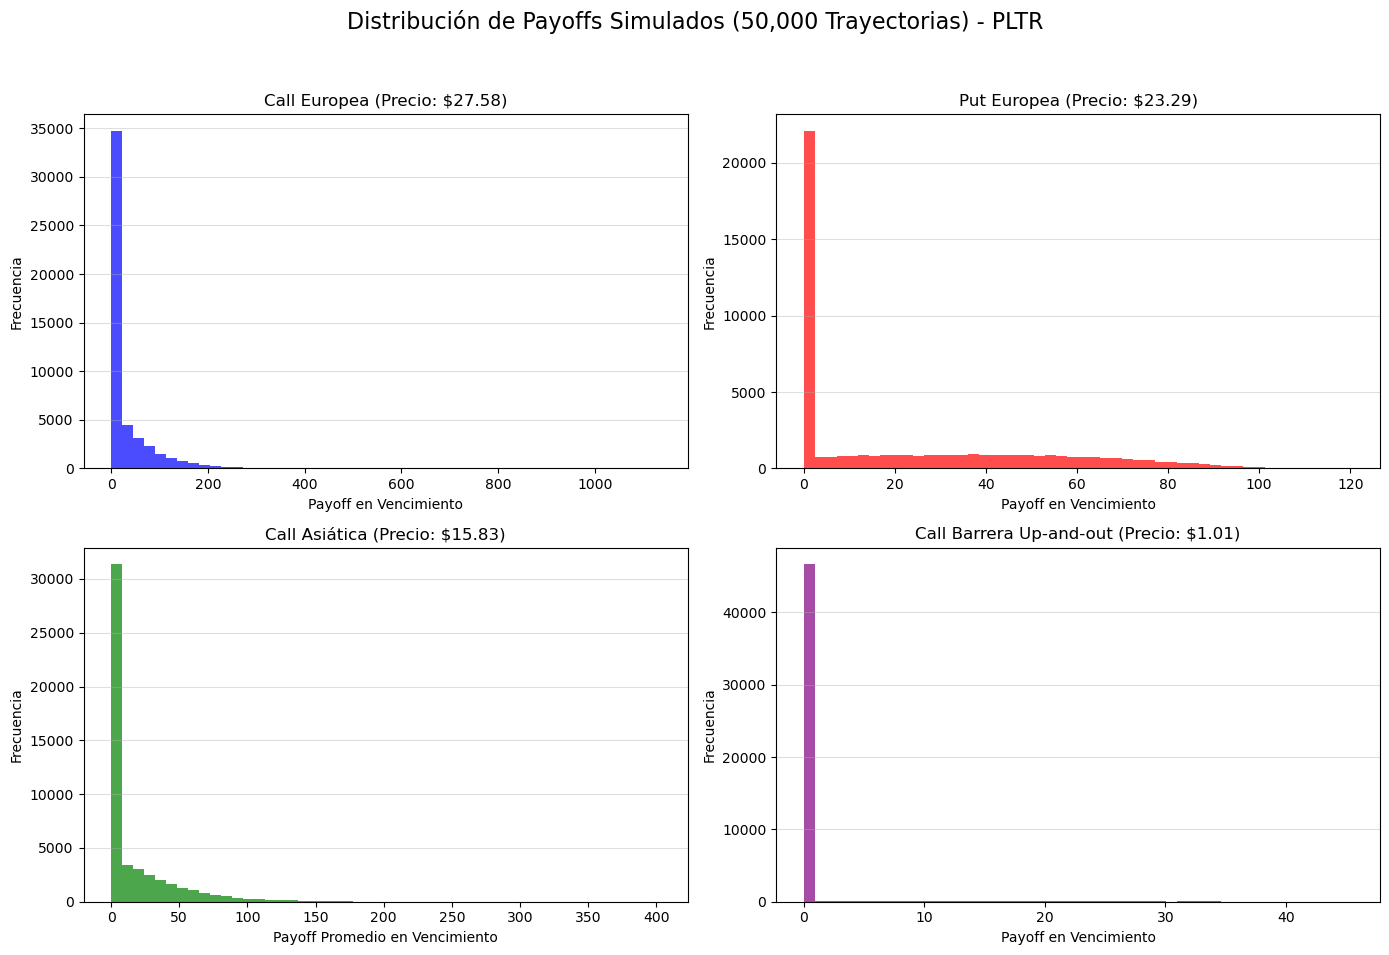

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ticker_symbol = 'PLTR'

stock_data = yf.download(ticker_symbol, period="1y", progress=False)

S0 = float(stock_data['Close'].iloc[-1].item() if isinstance(stock_data['Close'].iloc[-1], pd.Series) else stock_data['Close'].iloc[-1])
K = float(round(S0))

log_returns = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
sigma = float(log_returns.std().item() if isinstance(log_returns.std(), pd.Series) else log_returns.std()) * np.sqrt(252)

try:
    rf_data = yf.download("^IRX", period="5d", progress=False)
    r_val = rf_data['Close'].iloc[-1].item() if isinstance(rf_data['Close'].iloc[-1], pd.Series) else rf_data['Close'].iloc[-1]
    r = float(r_val) / 100.0
except:
    r = 0.05

T = 1.0 
B = S0 * 1.35 

print("="*60)
print(f"PARÁMETROS CALCULADOS DINÁMICAMENTE (Activo: {ticker_symbol})")
print(f"S0 (Spot):       ${S0:.2f}")
print(f"K (Strike ATM):  ${K:.2f}")
print(f"T (Tiempo):      {T} año")
print(f"r (Tasa Libre):  {r*100:.2f}%")
print(f"Sigma (Vol):     {sigma*100:.2f}%")
print(f"Barrera (B):     ${B:.2f}")
print("="*60)

np.random.seed(42) 
M = 50000          
N = 252            
dt = T / N

Z = np.random.standard_normal((M, N))

S_paths = np.zeros((M, N + 1))
S_paths[:, 0] = S0

factor_drift = (r - 0.5 * sigma**2) * dt
factor_shock = sigma * np.sqrt(dt)

for t in range(1, N + 1):
    S_paths[:, t] = S_paths[:, t-1] * np.exp(factor_drift + factor_shock * Z[:, t-1])

S_T = S_paths[:, -1] 

descuento = np.exp(-r * T)

payoff_call_eur = np.maximum(S_T - K, 0)
precio_call_eur = np.mean(payoff_call_eur) * descuento

payoff_put_eur = np.maximum(K - S_T, 0)
precio_put_eur = np.mean(payoff_put_eur) * descuento

S_mean = np.mean(S_paths[:, 1:], axis=1) 
payoff_call_asiatica = np.maximum(S_mean - K, 0)
precio_call_asiatica = np.mean(payoff_call_asiatica) * descuento

max_tocado = np.max(S_paths, axis=1)
payoff_call_barrera = np.where(max_tocado < B, np.maximum(S_T - K, 0), 0)
precio_call_barrera = np.mean(payoff_call_barrera) * descuento

resultados = pd.DataFrame({
    'Tipo de Opción': ['Call Europea', 'Put Europea', 'Call Asiática', 'Call Barrera (Up & Out)'],
    'Precio Estimado (MC)': [precio_call_eur, precio_put_eur, precio_call_asiatica, precio_call_barrera]
})

print("\nTABLA COMPARATIVA DE PRECIOS")
print(resultados.to_string(index=False, float_format=lambda x: f"${x:.2f}"))


fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Distribución de Payoffs Simulados (50,000 Trayectorias) - {ticker_symbol}', fontsize=16)

axs[0, 0].hist(payoff_call_eur, bins=50, color='blue', alpha=0.7)
axs[0, 0].set_title(f'Call Europea (Precio: ${precio_call_eur:.2f})')
axs[0, 0].set_xlabel('Payoff en Vencimiento')
axs[0, 0].set_ylabel('Frecuencia')
axs[0, 0].grid(axis='y', alpha=0.4)

axs[0, 1].hist(payoff_put_eur, bins=50, color='red', alpha=0.7)
axs[0, 1].set_title(f'Put Europea (Precio: ${precio_put_eur:.2f})')
axs[0, 1].set_xlabel('Payoff en Vencimiento')
axs[0, 1].set_ylabel('Frecuencia')
axs[0, 1].grid(axis='y', alpha=0.4)

axs[1, 0].hist(payoff_call_asiatica, bins=50, color='green', alpha=0.7)
axs[1, 0].set_title(f'Call Asiática (Precio: ${precio_call_asiatica:.2f})')
axs[1, 0].set_xlabel('Payoff Promedio en Vencimiento')
axs[1, 0].set_ylabel('Frecuencia')
axs[1, 0].grid(axis='y', alpha=0.4)

axs[1, 1].hist(payoff_call_barrera, bins=50, color='purple', alpha=0.7)
axs[1, 1].set_title(f'Call Barrera Up-and-out (Precio: ${precio_call_barrera:.2f})')
axs[1, 1].set_xlabel('Payoff en Vencimiento')
axs[1, 1].set_ylabel('Frecuencia')
axs[1, 1].grid(axis='y', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Análisis de Payoffs y Diferencias en Precios

A partir de los resultados de mi simulación en Monte Carlo, la diferencia de precios entre las opciones exóticas y la europea estándar se justifica directamente por cómo está diseñado matemáticamente su *payoff*:

**1. Opción Call Asiática ($15.83) vs. Call Europea ($27.58):**
La característica clave del *payoff* de la Call Asiática es que se calcula sobre el **promedio aritmético** de los precios a lo largo de toda la trayectoria del año, no tomando únicamente el precio final en el vencimiento. Al utilizar este promedio, los picos extremos de ganancia (que son muy probables dada la altísima volatilidad del 50.78% que arrojó PLTR) se diluyen irremediablemente al mezclarse con los días donde la acción cotizó más bajo. Esta característica reduce drásticamente la varianza del resultado y recorta las ganancias extremas. Al tener un techo implícito en el potencial de ganancia debido a la promediación, el precio de la opción cae a $15.83, un descuento muy claro frente a los $27.58 de la Europea estándar.

**2. Opción Call con Barrera Up-and-Out ($1.01) vs. Call Europea ($27.58):**
La característica definitoria de este *payoff* es la cláusula de **"muerte anticipada" (Out)**. Si en algún momento del año el precio toca mi barrera de $175.57, la opción se cancela automáticamente y el *payoff* es cero absoluto. Con un plazo de un año completo y una volatilidad masiva del 50.78%, mis trayectorias simuladas demuestran que la probabilidad estadística de experimentar un shock alcista que toque la barrera es inmensa. Al amputar por completo el potencial de ganancias ilimitadas (a diferencia de la Europea, que me premiaría por ese mismo movimiento brusco al alza), el derivado pierde prácticamente toda su utilidad y su valor se desploma, cotizando en apenas $1.01.